# RealMLP Approach on Predicting Heart Disease

Purpose:


### Package import

In [ ]:
!pip install pytabkit -q

from pathlib import Path
import json
import zipfile
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import warnings
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ---- Config ----
COMP_SLUG = "playground-series-s6e2"
KAGGLE_COMP_DIR = Path("/kaggle/input/competitions/playground-series-s6e2")
KAGGLE_EXT_PATH = Path("/kaggle/input/datasets/neurocipher/heartdisease/Heart_Disease_Prediction.csv")

LOCAL_DATA_DIR = Path("data/raw")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

NEED_FILES = ["train.csv", "test.csv", "sample_submission.csv"]

In [ ]:
def run(cmd: list[str]) -> None:
    p = subprocess.run(cmd, capture_output=True, text=True)
    p.check_returncode()


def ensure_kaggle_cli() -> None:
    try:
        pass
    except Exception:
        subprocess.check_call(["pip", "-q", "install", "kaggle"])


def ensure_kaggle_json_interactive_colab(dst: Path = Path("/content/kaggle.json")) -> Path:
    """
    In Colab: open upload dialog if /content/kaggle.json is missing.
    In non-Colab: just require the file to exist.
    """
    if dst.exists():
        print("Found:", dst)
        return dst

    try:
        from google.colab import files  # type: ignore
    except Exception:
        raise FileNotFoundError(
            f"{dst} not found. Please place kaggle.json at {dst} (Colab) "
            "or provide credentials another way."
        )

    print("Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)")
    uploaded = files.upload()
    cand = None
    if "kaggle.json" in uploaded:
        cand = "kaggle.json"
    else:
        for name in uploaded.keys():
            if name.endswith(".json"):
                cand = name
                break
    if cand is None:
        raise FileNotFoundError("Upload failed: no .json file received.")

    Path(cand).rename(dst)
    print("Saved to:", dst)
    return dst


def install_kaggle_json(src: Path) -> None:
    """
    Copy /content/kaggle.json -> ~/.kaggle/kaggle.json (chmod 600)
    """
    if not src.exists():
        raise FileNotFoundError(f"{src} not found.")

    dst_dir = Path.home() / ".kaggle"
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / "kaggle.json"

    dst.write_bytes(src.read_bytes())
    try:
        dst.chmod(0o600)
    except Exception:
        pass

    cfg = json.loads(dst.read_text())
    if "username" not in cfg or "key" not in cfg:
        raise ValueError("kaggle.json is missing 'username' or 'key'.")
    print(f"Installed kaggle.json for user: {cfg['username']}")


def local_data_ready(data_dir: Path) -> bool:
    return all((data_dir / f).exists() for f in NEED_FILES)


def download_competition_to(data_dir: Path) -> None:
    """
    Download competition zip(s) and extract into data_dir.
    Assumes kaggle CLI + credentials are ready.
    """
    run(["kaggle", "config", "view"])
    run(["kaggle", "competitions", "download", "-c", COMP_SLUG, "-p", str(data_dir), "--force"])

    zips = list(data_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No zip found in {data_dir} after download.")

    for zp in zips:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(data_dir)
        print("Unzipped:", zp.name)

    if not local_data_ready(data_dir):
        missing = [f for f in NEED_FILES if not (data_dir / f).exists()]
        raise FileNotFoundError(f"Download/unzip finished but missing: {missing}")


In [ ]:
if KAGGLE_COMP_DIR.exists():
    DATA_SRC = "kaggle"
    data_dir = KAGGLE_COMP_DIR
    print("Using Kaggle mounted competition data:", data_dir)
else:
    DATA_SRC = "local"
    data_dir = LOCAL_DATA_DIR
    if local_data_ready(data_dir):
        print("Using local data (already present):", data_dir)
    else:
        print("Local data missing -> download using kaggle.json")
        ensure_kaggle_cli()
        kaggle_json_src = ensure_kaggle_json_interactive_colab(Path("/content/kaggle.json"))
        install_kaggle_json(kaggle_json_src)
        download_competition_to(data_dir)
        print("Download complete -> using local data:", data_dir)


# ---- Load ----
train = pd.read_csv(data_dir / "train.csv")
test  = pd.read_csv(data_dir / "test.csv")
sub   = pd.read_csv(data_dir / "sample_submission.csv")

# external dataset: only available if mounted on Kaggle; optional
original = pd.read_csv(KAGGLE_EXT_PATH) if KAGGLE_EXT_PATH.exists() else None

print("train:", train.shape, "test:", test.shape, "sub:", sub.shape, "original:", None if original is None else original.shape)
print("DATA_SRC:", DATA_SRC)


Using local data (already present): data/raw
train: (630000, 15) test: (270000, 14) sub: (270000, 2) original: None
DATA_SRC: local


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.set_float32_matmul_precision("high")
N_FOLDS = 5
USE_ALL_CAT = True

print(f"Using device: {DEVICE}")


Using device: cuda


### Data download

In [ ]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [ ]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 15)
test: (270000, 14)
Only in train: ['Heart Disease']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data Preprocessing

In [ ]:
def encode_target_strict(y: pd.Series) -> pd.Series:
    """Map common string labels to {0,1}. Raises if unknown."""
    mapping_candidates = [
        {"No": 0, "Yes": 1},
        {"N": 0, "Y": 1},
        {"Negative": 0, "Positive": 1},
        {"Absent": 0, "Present": 1},
        {"Absence": 0, "Presence": 1},
        {0: 0, 1: 1},
        {"0": 0, "1": 1},
    ]
    uniq = set(pd.Series(y).dropna().unique().tolist())
    for mp in mapping_candidates:
        if uniq.issubset(set(mp.keys())):
            return pd.Series(y).map(mp).astype("int8")
    raise ValueError(f"Unknown target labels: {sorted(list(uniq))}")


# ---- target ----
train["Heart Disease"] = encode_target_strict(train["Heart Disease"])
if original is not None and "Heart Disease" in original.columns:
    original["Heart Disease"] = encode_target_strict(original["Heart Disease"])

TARGET_COL = "Heart Disease"
ID_COL = "id"

BASE_FEATURES = [c for c in train.columns if c not in [TARGET_COL, ID_COL]]

# Canonical S6E2 semantic categoricals (keep as category for embeddings/encoding)
CANONICAL_CAT = {
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
}

def split_cols(df: pd.DataFrame):
    base = [c for c in df.columns if c not in [TARGET_COL, ID_COL]]
    cat = [c for c in base if c in CANONICAL_CAT]
    num = [c for c in base if c not in cat]
    return cat, num


def add_external_target_stats(df: pd.DataFrame, original_df: pd.DataFrame | None) -> pd.DataFrame:
    """Merge group-wise target stats from the external/original dataset.
    Safe in Playground comps because original_df labels are not the competition labels.
    """
    if original_df is None:
        return df.copy()

    out = df.copy()
    initial_rows = len(out)

    for col in BASE_FEATURES:
        if col not in original_df.columns:
            continue

        stats = (
            original_df.groupby(col)[TARGET_COL]
            .agg(["mean", "median", "std", "skew", "count"])
            .reset_index()
        )
        stats.columns = [col] + [f"orig_{col}_{s}" for s in ["mean", "median", "std", "skew", "count"]]

        out = out.merge(stats, on=col, how="left")
        if len(out) != initial_rows:
            raise ValueError(f"Merge expanded rows for column {col}! {initial_rows} -> {len(out)}")

        # fill NAs for unseen values
        global_mean = float(original_df[TARGET_COL].mean())
        global_median = float(original_df[TARGET_COL].median())
        fill = {
            f"orig_{col}_mean": global_mean,
            f"orig_{col}_median": global_median,
            f"orig_{col}_std": 0.0,
            f"orig_{col}_skew": 0.0,
            f"orig_{col}_count": 0.0,
        }
        out = out.fillna(value=fill)

    return out


def add_frequency_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Add {col}_freq columns using combined train+test frequencies (unsupervised, safe)."""
    tr = train_df.copy()
    te = test_df.copy()

    combined = pd.concat([tr[cols], te[cols]], axis=0, ignore_index=True)
    for col in cols:
        freq = combined[col].value_counts(dropna=False)
        tr[f"{col}_freq"] = tr[col].map(freq).astype("float32")
        te[f"{col}_freq"] = te[col].map(freq).astype("float32")
    return tr, te


def add_binned_numerics(train_df: pd.DataFrame, test_df: pd.DataFrame, num_cols: list[str], n_bins: int = 10):
    tr = train_df.copy()
    te = test_df.copy()

    for col in num_cols:
        allv = pd.concat([tr[col], te[col]], axis=0, ignore_index=True)

        # If low cardinality, just reuse as "bin" (stable int codes)
        if allv.nunique(dropna=False) <= n_bins:
            tr[f"{col}_bin"] = pd.Series(tr[col]).astype("int32", errors="ignore")
            te[f"{col}_bin"] = pd.Series(te[col]).astype("int32", errors="ignore")
            continue

        try:
            bins = pd.qcut(allv.rank(method="first"), q=n_bins, labels=False, duplicates="drop")
        except Exception:
            bins = pd.cut(allv, bins=n_bins, labels=False, duplicates="drop")

        tr[f"{col}_bin"] = bins.iloc[:len(tr)].astype("int16")
        te[f"{col}_bin"] = bins.iloc[len(tr):].astype("int16")

    return tr, te


def build_features(
    train_fe: pd.DataFrame,
    test_fe: pd.DataFrame,
    cat_cols: list[str],
    num_cols: list[str],
    use_bins: bool,
):
    tr = train_fe.copy()
    te = test_fe.copy()

    if use_bins:
        # Add binned versions of continuous numerics (helps linear/MLP; low risk for GBDT too)
        # Important: keep 'orig_*' stats as numeric; they are already in num_cols here.
        # bin only "base continuous" numerics (exclude orig_* stats)
        num_cols_for_bins = [c for c in num_cols if not c.startswith("orig_")]
        tr, te = add_binned_numerics(tr, te, num_cols_for_bins, n_bins=10)

    print(f"Train Shape after FE: {tr.shape}")
    print(f"Test Shape after FE:  {te.shape}")

    # ---- Build X/y with clean dtypes ----
    drop_tr = [c for c in [TARGET_COL, ID_COL] if c in tr.columns]
    drop_te = [c for c in [ID_COL] if c in te.columns]

    X = tr.drop(columns=drop_tr).copy()
    X_test = te.drop(columns=drop_te).copy()
    y = tr[TARGET_COL].copy()

    bin_cols = [c for c in X.columns if c.endswith("_bin")]

    cat_cols_final = [c for c in X.columns if c in cat_cols] + (bin_cols if use_bins else [])
    num_cols_final = [c for c in X.columns if c not in cat_cols_final]

    for c in cat_cols_final:
        combined = pd.concat([X[c], X_test[c]], axis=0, ignore_index=True)
        cats = pd.Categorical(combined).categories
        X[c] = pd.Categorical(X[c], categories=cats)
        X_test[c] = pd.Categorical(X_test[c], categories=cats)

    for c in num_cols_final:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce").astype("float32")

    return X, X_test, y, cat_cols_final, num_cols_final


# ---- Feature engineering (per EDA) ----
train_fe = add_external_target_stats(train, original)
test_fe  = add_external_target_stats(test, original)

cat_cols, num_cols = split_cols(train_fe)

# Frequency encoding for semantic categoricals
train_fe, test_fe = add_frequency_encoding(train_fe, test_fe, cat_cols)

CONFIGS = {
    "categorical_binned": True,
    "numeric_continuous": False,
}

features = {}
for name, use_bins in CONFIGS.items():
    print(f"=== Building features: {name} (use_bins={use_bins}) ===")
    X_tmp, X_test_tmp, y_tmp, cat_cols_final, num_cols_final = build_features(
        train_fe, test_fe, cat_cols, num_cols, use_bins
    )

    if use_bins:
        assert any(c.endswith("_bin") for c in X_tmp.columns)
    else:
        assert not any(c.endswith("_bin") for c in X_tmp.columns)

    assert all(str(X_tmp[c].dtype) == "category" for c in cat_cols_final)
    assert all(X_tmp[c].dtype == "float32" for c in num_cols_final)

    print("Categorical cols:", len(cat_cols_final))
    print("Numeric cols:", len(num_cols_final))

    features[name] = {
        "X": X_tmp,
        "X_test": X_test_tmp,
        "y": y_tmp,
        "cat_cols": cat_cols_final,
        "num_cols": num_cols_final,
    }

# Default config for downstream cells
PRIMARY_CONFIG = "categorical_binned"
X = features[PRIMARY_CONFIG]["X"]
X_test = features[PRIMARY_CONFIG]["X_test"]
y = features[PRIMARY_CONFIG]["y"]
cat_cols = features[PRIMARY_CONFIG]["cat_cols"]

print(f"\nPRIMARY_CONFIG={PRIMARY_CONFIG}")
print(f"X: {X.shape}, X_test: {X_test.shape}, y: {y.shape}")


=== Building features: categorical_binned (use_bins=True) ===
Train Shape after FE: (630000, 28)
Test Shape after FE:  (270000, 27)
Categorical cols: 13
Numeric cols: 13
=== Building features: numeric_continuous (use_bins=False) ===
Train Shape after FE: (630000, 23)
Test Shape after FE:  (270000, 22)
Categorical cols: 8
Numeric cols: 13

PRIMARY_CONFIG=categorical_binned
X: (630000, 26), X_test: (270000, 26), y: (630000,)


### Data Quality Check

In [ ]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()

    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


### Feature Uniqueness & Cardinality

In [ ]:
def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id':
            continue

        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"

        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess
        })

    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

uniqueness_df = analyze_uniqueness(train)
uniqueness_df

,Feature,Unique Values,Data Type,Heuristic Type
1,Sex,2,int64,Categorical/Ordinal
5,FBS over 120,2,int64,Categorical/Ordinal
13,Heart Disease,2,int8,Categorical/Ordinal
8,Exercise angina,2,int64,Categorical/Ordinal
10,Slope of ST,3,int64,Categorical/Ordinal
12,Thallium,3,int64,Categorical/Ordinal
6,EKG results,3,int64,Categorical/Ordinal
2,Chest pain type,4,int64,Categorical/Ordinal
11,Number of vessels fluro,4,int64,Categorical/Ordinal
0,Age,42,int64,Continuous


### Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
EKG results_freq       -16.972622
FBS over 120_freq       -3.096606
Slope of ST_freq        -1.947209
Thallium_freq           -1.354339
ST depression            1.328429
Exercise angina_freq    -1.014983
dtype: float32


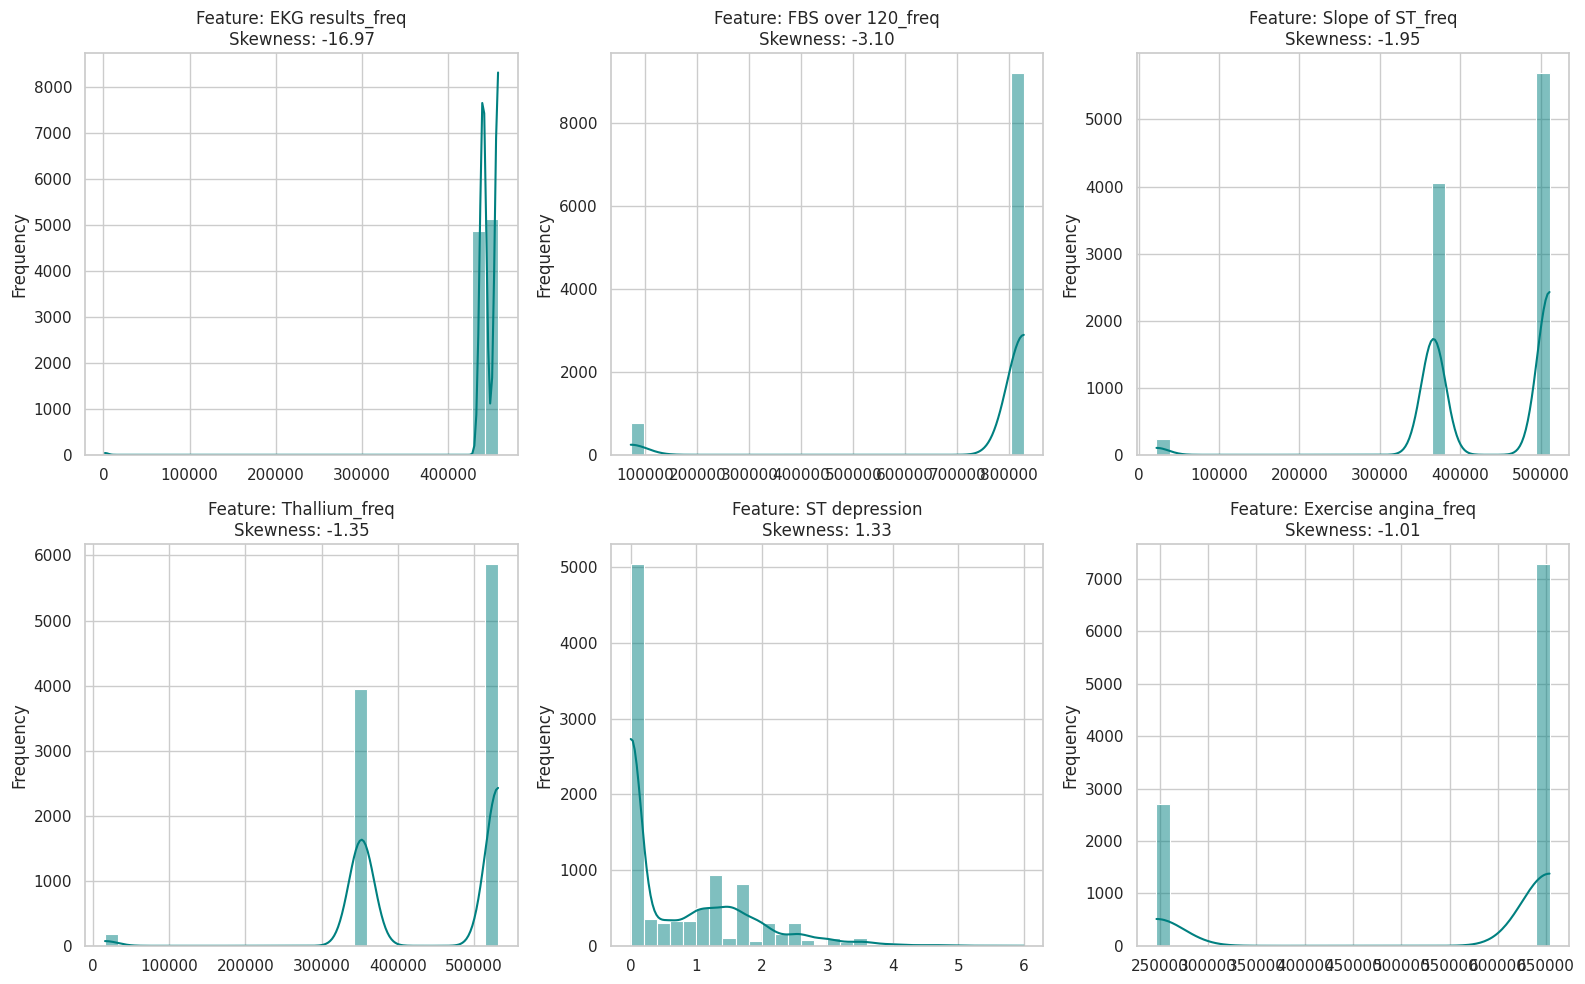

In [ ]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Train vs Test Alignment (KS test + Adversarial Validation)

The EDA notes suggest train/test are well-aligned. We'll verify quickly with a KS test for numeric columns and an adversarial classifier.


In [ ]:
from scipy.stats import ks_2samp
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# KS test: sample for speed (still meaningful)
KS_SAMPLE = 100_000
ks_rows = []
for col in [c for c in X.columns if X[c].dtype != "category"]:
    a = X[col].sample(min(KS_SAMPLE, len(X)), random_state=RANDOM_STATE).astype("float32")
    b = X_test[col].sample(min(KS_SAMPLE, len(X_test)), random_state=RANDOM_STATE).astype("float32")
    stat, p = ks_2samp(a, b)
    ks_rows.append((col, float(stat), float(p)))

ks_df = pd.DataFrame(ks_rows, columns=["feature","ks_stat","p_value"]).sort_values("ks_stat", ascending=False)
display(ks_df.head(15))

# Adversarial validation (sampled for speed)
ADV_SAMPLE = 200_000
adv_X = pd.concat([X, X_test], axis=0, ignore_index=True)
adv_y = np.r_[np.zeros(len(X), dtype=np.int8), np.ones(len(X_test), dtype=np.int8)]

idx = np.random.RandomState(RANDOM_STATE).choice(len(adv_X), size=min(ADV_SAMPLE, len(adv_X)), replace=False)
adv_Xs = adv_X.iloc[idx].copy()
adv_ys = adv_y[idx]

cat_cols_adv = [c for c in adv_Xs.columns if adv_Xs[c].dtype == 'category']
num_cols_adv = [c for c in adv_Xs.columns if adv_Xs[c].dtype != 'category']
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)
pre = ColumnTransformer([
    ('cat', ohe, cat_cols_adv),
    ('num', 'passthrough', num_cols_adv),
], remainder='drop')

adv_model = LogisticRegression(max_iter=200, solver="saga", n_jobs=-1)
adv_pipe = Pipeline([("pre", pre), ("clf", adv_model)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
aucs = []
for tr_idx, va_idx in skf.split(adv_Xs, adv_ys):
    adv_pipe.fit(adv_Xs.iloc[tr_idx], adv_ys[tr_idx])
    pred = adv_pipe.predict_proba(adv_Xs.iloc[va_idx])[:,1]
    aucs.append(roc_auc_score(adv_ys[va_idx], pred))
print("Adversarial AUC (mean ± std):", float(np.mean(aucs)), "±", float(np.std(aucs)))


,feature,ks_stat,p_value
5,Sex_freq,0.00467,0.224858
1,BP,0.00283,0.816995
3,Max HR,0.00266,0.870136
0,Age,0.00227,0.958366
4,ST depression,0.00219,0.969731
6,Chest pain type_freq,0.00216,0.973407
2,Cholesterol,0.00188,0.994331
12,Thallium_freq,0.00084,1.000000
7,FBS over 120_freq,0.00077,1.000000
8,EKG results_freq,0.00063,1.000000


Adversarial AUC (mean ± std): 0.501179992230797 ± 0.002036553167669711


### Cross-Validation & Training

In [ ]:
%%time

# ---------------------------
# Hyperparameter Optimization
# ---------------------------
HPO_ENABLED = True
HPO_CONFIG = "numeric_continuous"  # fixed for HPO
HPO_N_TRIALS = 30
HPO_VALID_SIZE = 0.2
HPO_EVAL = "holdout"  # "holdout" or "cv" for stage 1
HPO_CV_FOLDS = 3
HPO_RANDOM_STATE = RANDOM_STATE
HPO_TOPK_CV = 8  # re-evaluate top-K with CV for stability

base_params = {
        # core training settings (fixed during HPO)
        'random_state': RANDOM_STATE,
        'verbosity': 1,
        'n_epochs': 50,   # light for HPO
        'n_ens': 1,       # light for HPO
        'use_early_stopping': True,
        'early_stopping_additive_patience': 20,
        'early_stopping_multiplicative_patience': 1,
        'val_metric_name': '1-auc_ovr',
        # architecture / embedding defaults (some tuned, others sampled)
        'hidden_sizes': "rectangular",
        'max_one_hot_cat_size': 18,
        'ls_eps_sched': "coslog4",
        'p_drop_sched': "flat_cos",
        # PLR defaults (kept fixed here for stability)
        'plr_hidden_1': 16,
        'plr_hidden_2': 8,
        'plr_sigma': 2.0,
        # misc defaults
        'embedding_size': 8,
    }

base_params['device'] = DEVICE


def make_model(param_grid, cat_cols):
    try:
        return RealMLP_TD_Classifier(**param_grid, cat_col_names=cat_cols)
    except TypeError:
        # Older pytabkit versions may not support cat_col_names
        return RealMLP_TD_Classifier(**param_grid)


def _loguniform(rng, low, high):
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))


def sample_params(rng):
    params = dict(base_params)
    params.update({
        'act': rng.choice(["mish", "relu", "silu"]),
        'batch_size': int(rng.choice([128, 256, 512])),
        'hidden_width': int(rng.choice([128, 256, 384, 512, 768])),
        'n_hidden_layers': int(rng.choice([2, 3, 4, 5])),
        'lr': _loguniform(rng, 1e-3, 8e-2),
        'wd': _loguniform(rng, 1e-5, 5e-2),
        'p_drop': float(rng.uniform(0.0, 0.3)),
        'ls_eps': _loguniform(rng, 1e-4, 5e-2),
        'first_layer_lr_factor': _loguniform(rng, 0.2, 1.0),
        'scale_lr_factor': _loguniform(rng, 0.5, 4.0),
        'plr_lr_factor': _loguniform(rng, 0.05, 0.5),
        'sq_mom': 1.0 - _loguniform(rng, 1e-4, 3e-2),
    })
    return params


def eval_params_holdout(params, X, y, cat_cols):
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=HPO_VALID_SIZE, stratify=y, random_state=HPO_RANDOM_STATE
    )
    model = make_model(params, cat_cols)
    model.fit(X_tr, y_tr.values, X_val, y_val.values)
    val_probs = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, val_probs)
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return float(score)


def eval_params_cv(params, X, y, cat_cols):
    skf = StratifiedKFold(n_splits=HPO_CV_FOLDS, shuffle=True, random_state=HPO_RANDOM_STATE)
    fold_scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[va_idx]
        model = make_model(params, cat_cols)
        model.fit(X_tr, y_tr.values, X_val, y_val.values)
        val_probs = model.predict_proba(X_val)[:, 1]
        fold_scores.append(roc_auc_score(y_val, val_probs))
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    return float(np.mean(fold_scores))


if HPO_ENABLED:
    print(f"Running HPO on config: {HPO_CONFIG} | trials={HPO_N_TRIALS} | eval={HPO_EVAL}")
    X_hpo = features[HPO_CONFIG]["X"]
    y_hpo = features[HPO_CONFIG]["y"]
    cat_cols_hpo = features[HPO_CONFIG]["cat_cols"]

    rng = np.random.RandomState(HPO_RANDOM_STATE)
    hpo_rows = []
    best_score = -1.0
    best_params = None

    for t in range(1, HPO_N_TRIALS + 1):
        params = sample_params(rng)
        try:
            if HPO_EVAL == "cv":
                score = eval_params_cv(params, X_hpo, y_hpo, cat_cols_hpo)
            else:
                score = eval_params_holdout(params, X_hpo, y_hpo, cat_cols_hpo)
        except Exception as e:
            print(f"Trial {t:02d} failed: {e}")
            continue

        row = {"trial": t, "score": score, "params": params}
        row.update({k: params[k] for k in [
            "act", "batch_size", "hidden_width", "n_hidden_layers",
            "lr", "wd", "p_drop", "ls_eps", "first_layer_lr_factor",
            "scale_lr_factor", "plr_lr_factor", "sq_mom",
        ]})
        hpo_rows.append(row)

        if score > best_score:
            best_score = score
            best_params = params
            print(f"Trial {t:02d} | best_score={best_score:.5f}")

    hpo_results_df = pd.DataFrame(hpo_rows).sort_values("score", ascending=False)
    display(hpo_results_df.drop(columns=["params"]).head(10))

    if best_params is None:
        raise RuntimeError("HPO did not produce a valid configuration.")

    # Optional stage-2: re-evaluate top-K with CV for stability
    if HPO_EVAL == "holdout" and HPO_TOPK_CV > 0:
        topk = hpo_results_df.head(HPO_TOPK_CV)
        cv_rows = []
        for _, r in topk.iterrows():
            params = r["params"]
            score = eval_params_cv(params, X_hpo, y_hpo, cat_cols_hpo)
            cv_rows.append({"trial": r["trial"], "cv_score": score, "params": params})
        cv_df = pd.DataFrame(cv_rows).sort_values("cv_score", ascending=False)
        display(cv_df.drop(columns=["params"]))
        best_params = cv_df.iloc[0]["params"]
        best_score = float(cv_df.iloc[0]["cv_score"])

    print("Best HPO score:", best_score)
    print("Best params:")
    display(pd.Series(best_params))

    param_grid = best_params
else:
    # fallback to base params if HPO is disabled
    param_grid = dict(base_params)

# ensure device is set
param_grid['device'] = DEVICE

# ---------------------------
# Cross-Validation & Training
# ---------------------------
# Heavier settings for final CV
param_grid['n_epochs'] = 100
param_grid['n_ens'] = 8


def run_realmlp_cv(X, X_test, y, cat_cols, param_grid, n_folds, random_state):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    oof_preds = np.zeros(len(X), dtype=np.float32)
    test_preds = np.zeros(len(X_test), dtype=np.float32)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"--- Starting Fold {fold + 1} ---")

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = make_model(param_grid, cat_cols)
        model.fit(X_tr, y_tr.values, X_val, y_val.values)

        val_probs = model.predict_proba(X_val)[:, 1]
        fold_test_probs = model.predict_proba(X_test)[:, 1]

        oof_preds[val_idx] = val_probs
        test_preds += fold_test_probs / n_folds

        score = roc_auc_score(y_val, val_probs)
        fold_scores.append(score)
        print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "fold_scores": fold_scores,
        "mean_auc": float(np.mean(fold_scores)),
        "std_auc": float(np.std(fold_scores)),
    }


feat = features[HPO_CONFIG]
res = run_realmlp_cv(
    feat["X"],
    feat["X_test"],
    feat["y"],
    feat["cat_cols"],
    param_grid,
    N_FOLDS,
    RANDOM_STATE,
)
results = {HPO_CONFIG: res}

rows = []
for name, res in results.items():
    row = {
        "config": name,
        "mean_auc": res["mean_auc"],
        "std_auc": res["std_auc"],
    }
    for i, score in enumerate(res["fold_scores"]):
        row[f"fold_{i+1}"] = score
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
print("Comparison summary:")
display(results_df)

# Select primary config for downstream cells
PRIMARY_CONFIG = "numeric_continuous"
X = features[PRIMARY_CONFIG]["X"]
X_test = features[PRIMARY_CONFIG]["X_test"]
y = features[PRIMARY_CONFIG]["y"]
cat_cols = features[PRIMARY_CONFIG]["cat_cols"]

oof_preds = results[PRIMARY_CONFIG]["oof_preds"]
test_preds = results[PRIMARY_CONFIG]["test_preds"]
fold_scores = results[PRIMARY_CONFIG]["fold_scores"]



===== RealMLP: categorical_binned =====

--- Starting Fold 1 ---
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Age_bin', 'BP_bin', 'Cholesterol_bin', 'Max HR_bin', 'ST depression_bin']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/100: val 1-auc_ovr = 0.045554
Epoch 2/100: val 1-auc_ovr = 0.045526
Epoch 3/100: val 1-auc_ovr = 0.045300
Epoch 4/100: val 1-auc_ovr = 0.045083
Epoch 5/100: val 1-auc_ovr = 0.044875
Epoch 6/100: val 1-auc_ovr = 0.044760
Epoch 7/100: val 1-auc_ovr = 0.044721
Epoch 8/100: val 1-auc_ovr = 0.044838
Epoch 9/100: val 1-auc_ovr = 0.044826
Epoch 10/100: val 1-auc_ovr = 0.044950
Epoch 11/100: val 1-auc_ovr = 0.045027
Epoch 12/100: val 1-auc_ovr = 0.044931
Epoch 13/100: val 1-auc_ovr = 0.045049
Epoch 14/100: val 1-auc_ovr = 0.044913
Epoch 15/100: val 1-auc_ovr = 0.044821
Epoch 16/100: val 1-auc_ovr = 0.044687
Epoch 17/100: val 1-auc_ovr = 0.044674
Epoch 18/100: val 1-auc_ovr = 0.044586
Epoch 19/100: val 1-auc_ovr = 0.044539
Epoch 20/100: val 1-auc_ovr = 0.044534
Epoch 21/100: val 1-auc_ovr = 0.044524
Epoch 22/100: val 1-auc_ovr = 0.044541
Epoch 23/100: val 1-auc_ovr = 0.044601
Epoch 24/100: val 1-auc_ovr = 0.044644
Epoch 25/100: val 1-auc_ovr = 0.044778
Epoch 26/100: val 1-auc_ovr = 0.04

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud

Fold 1 ROC-AUC Score: 0.95548

--- Starting Fold 2 ---
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Age_bin', 'BP_bin', 'Cholesterol_bin', 'Max HR_bin', 'ST depression_bin']


...

Epoch 1/100: val 1-auc_ovr = 0.045572
Epoch 2/100: val 1-auc_ovr = 0.045373
Epoch 3/100: val 1-auc_ovr = 0.045179
Epoch 4/100: val 1-auc_ovr = 0.044924
Epoch 5/100: val 1-auc_ovr = 0.044755
Epoch 6/100: val 1-auc_ovr = 0.044661
Epoch 7/100: val 1-auc_ovr = 0.044632
Epoch 8/100: val 1-auc_ovr = 0.044690
Epoch 9/100: val 1-auc_ovr = 0.044720
Epoch 10/100: val 1-auc_ovr = 0.044903
Epoch 11/100: val 1-auc_ovr = 0.045006
Epoch 12/100: val 1-auc_ovr = 0.044873
Epoch 13/100: val 1-auc_ovr = 0.044770
Epoch 14/100: val 1-auc_ovr = 0.044947
Epoch 15/100: val 1-auc_ovr = 0.044614
Epoch 16/100: val 1-auc_ovr = 0.044540
Epoch 17/100: val 1-auc_ovr = 0.044466
Epoch 18/100: val 1-auc_ovr = 0.044410
Epoch 19/100: val 1-auc_ovr = 0.044357
Epoch 20/100: val 1-auc_ovr = 0.044348
Epoch 21/100: val 1-auc_ovr = 0.044336
Epoch 22/100: val 1-auc_ovr = 0.044379
Epoch 23/100: val 1-auc_ovr = 0.044396
Epoch 24/100: val 1-auc_ovr = 0.044628
Epoch 25/100: val 1-auc_ovr = 0.044567
Epoch 26/100: val 1-auc_ovr = 0.04

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud

Fold 5 ROC-AUC Score: 0.95566
Comparison summary:


,config,mean_auc,std_auc,fold_1,fold_2,fold_3,fold_4,fold_5
0,categorical_binned,0.955096,0.000409,0.955476,0.954480,0.955103,0.954832,0.955590
1,numeric_continuous,0.955078,0.000472,0.955515,0.954401,0.955082,0.954731,0.955664


Delta (numeric_continuous - categorical_binned) mean AUC: -0.000018
CPU times: user 2h 14min 13s, sys: 2min 43s, total: 2h 16min 56s
Wall time: 2h 18min 13s


### Model Evaluation

In [ ]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5))
plt.suptitle('RealMLP', fontsize=20)

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Evaluation and Submission

In [ ]:
total_oof_score = roc_auc_score(y, oof_preds)

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC: {total_oof_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")
print("="*40)

In [ ]:
# Fold Scores Table
fold_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(N_FOLDS)],
    'ROC-AUC': fold_scores
})
fold_df

In [ ]:
submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(f'Shape: {submission.shape}')

if len(submission) != 270000:
    raise ValueError(f"CRITICAL ERROR: Submission row count {len(submission)} != expected 270000")

submission.head()